# Calculating solar position in Python

This tutorial demonstrates how to calculate solar positions in Python using the [pvlib-python](https://pvlib-python.readthedocs.io/) library.


The first step is to import a few Python packages.

👉 Install pvlib by executing the cell below. You can do this using ctrl+enter or shift+enter, or clicking the run button on the cell.

In [1]:
# Install pvlib on Google Colab as this is not a standard package.
!pip install pvlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 29.2 MB/s eta 0:00:00


In [2]:
import pvlib  # library for PV and solar calculations
import pandas as pd  # library for data analysis
import matplotlib.pyplot as plt  # library for plotting

## Step 1: Define a location

A location is defined by a latitude and longitude according to the convention of [ISO 6709](https://en.wikipedia.org/wiki/ISO_6709). Specifically, latitude is in degrees north of the equator and the longitude is in degrees east of the prime meridian.

👉 Fill in the latitude and longitude of DTU in the code cell below.

In [3]:
location = pvlib.location.Location(
    latitude=55.790497,
    longitude=12.525573,
)

## Step 2: Define time stamps

The next step is to define the time stamps for which you want to calculate solar positions for. Here it is important to specify the timezone as otherwise UTC will be assumed.

For more information on available timezones, see the [pvlib documentation on timezones](https://pvlib-python.readthedocs.io/en/stable/user_guide/modeling_topics/timetimezones.html).

In [6]:
times = pd.date_range(
    start='2025-09-01 00:00',
    end='2025-09-01 23:59',
    freq='1min',  # frequency
    tz='Europe/Copenhagen',  # timezone
)

times

DatetimeIndex(['2025-09-01 00:00:00+02:00', '2025-09-01 00:01:00+02:00',
               '2025-09-01 00:02:00+02:00', '2025-09-01 00:03:00+02:00',
               '2025-09-01 00:04:00+02:00', '2025-09-01 00:05:00+02:00',
               '2025-09-01 00:06:00+02:00', '2025-09-01 00:07:00+02:00',
               '2025-09-01 00:08:00+02:00', '2025-09-01 00:09:00+02:00',
               ...
               '2025-09-01 23:50:00+02:00', '2025-09-01 23:51:00+02:00',
               '2025-09-01 23:52:00+02:00', '2025-09-01 23:53:00+02:00',
               '2025-09-01 23:54:00+02:00', '2025-09-01 23:55:00+02:00',
               '2025-09-01 23:56:00+02:00', '2025-09-01 23:57:00+02:00',
               '2025-09-01 23:58:00+02:00', '2025-09-01 23:59:00+02:00'],
              dtype='datetime64[ns, Europe/Copenhagen]', length=1440, freq='min')

## Step 3: Calculate solar position

Once we have defined a location and the time stamps for which we want to calculate solar position for, we can use the convenient ``.get_solarposition`` function of the location class to calculate the solar positions.

👉 Execute the code cell below and inspect the output. What columns are available?

In [7]:
solpos = location.get_solarposition(times)

solpos.head()  # Print the first 5 rows

,apparent_zenith,zenith,apparent_elevation,elevation,azimuth,equation_of_time
2025-09-01 00:00:00+02:00,114.292044,114.292044,-24.292044,-24.292044,340.938220,-0.126293
2025-09-01 00:01:00+02:00,114.337894,114.337894,-24.337894,-24.337894,341.205042,-0.126073
2025-09-01 00:02:00+02:00,114.383125,114.383125,-24.383125,-24.383125,341.472087,-0.125853
2025-09-01 00:03:00+02:00,114.427734,114.427734,-24.427734,-24.427734,341.739354,-0.125633
2025-09-01 00:04:00+02:00,114.471721,114.471721,-24.471721,-24.471721,342.006839,-0.125413


## Step 4: Plot the solar position

👉 Plot the solar elevation and azimuth below

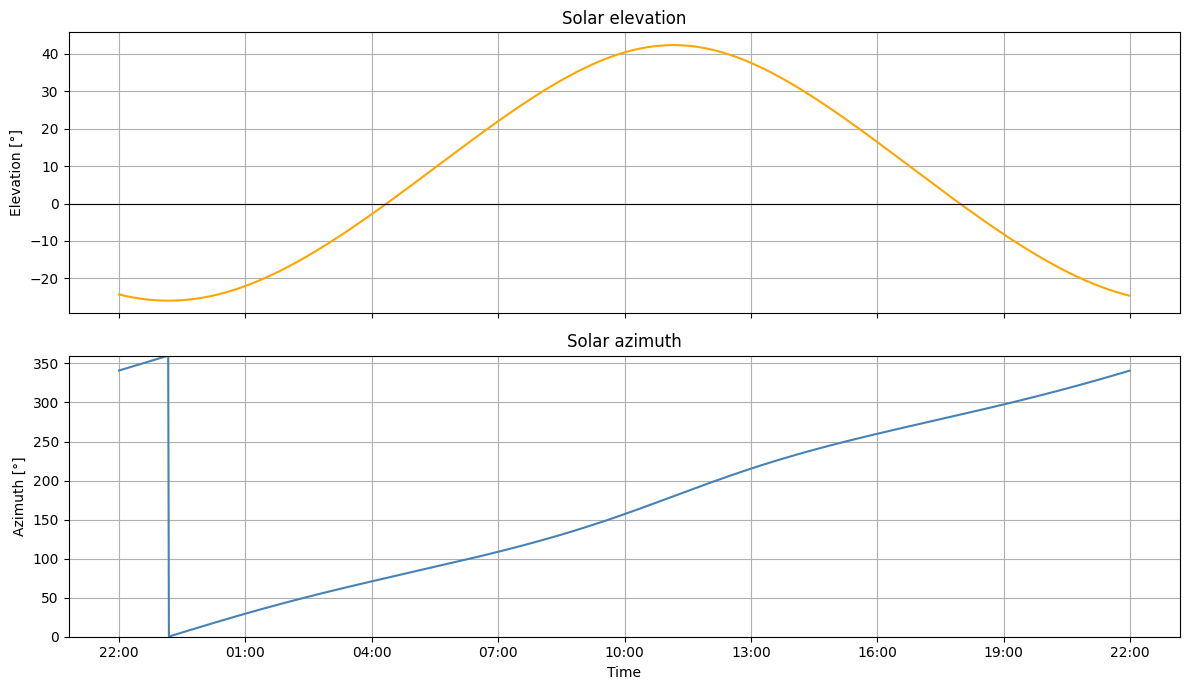

In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Plot solar elevation
axes[0].plot(solpos.index, solpos["elevation"], color="orange")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("Elevation [°]")
axes[0].set_title("Solar elevation")
axes[0].grid(True)

# Plot solar azimuth
axes[1].plot(solpos.index, solpos["azimuth"], color="steelblue")
axes[1].set_ylabel("Azimuth [°]")
axes[1].set_xlabel("Time")
axes[1].set_title("Solar azimuth")
axes[1].set_ylim(0, 360)
axes[1].grid(True)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.tight_layout()
plt.show()

## Step 5: Calculate atmospheric refraction

👉 In the final step you will need to calculate the atmospheric refraction for the day. Note, the information that you need is available in the ``solpos`` DataFrame.

In [ ]:
# Write your code here to calculate refraction


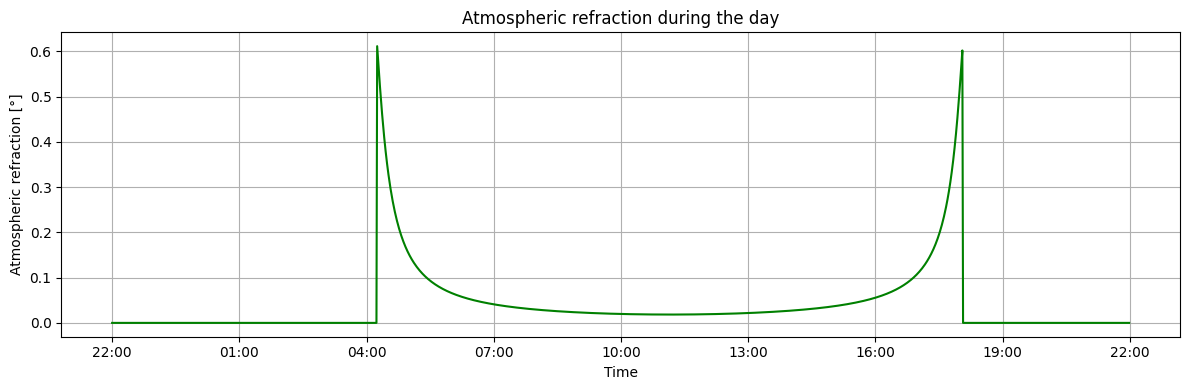

In [9]:
# Calculate atmospheric refraction
solpos["atmospheric_refraction"] = (
    solpos["apparent_elevation"] - solpos["elevation"]
)

# Plot atmospheric refraction
plt.figure(figsize=(12, 4))

plt.plot(
    solpos.index,
    solpos["atmospheric_refraction"],
    color="green"
)

plt.xlabel("Time")
plt.ylabel("Atmospheric refraction [°]")
plt.title("Atmospheric refraction during the day")
plt.grid(True)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.tight_layout()
plt.show()